# Isoprene Sensitivity Studies

---
Last modified: February 6th, 2025 (JY)

This notebook uses a modified version of vSmartMOM with functions specifically for isoprene to calculate radiances with different amounts of isoprene/water vapor/aerosols/etc.

This notebook is coded in Julia.

In [147]:
# Activate Julia packages
using Pkg;
using Revise;

Pkg.activate("vSmartMOM_ISOP.jl");
Pkg.instantiate();

# Using local module, since the current version of vSmartMOM does not support isoprene (not a HITRAN line list species)
include("vSmartMOM_ISOP.jl/src/vSmartMOM.jl");

# Other imports
using Statistics, PlutoUI, Polynomials, PlotlyBase, Plots, LazyArtifacts, LinearAlgebra, NCDatasets, Format, LaTeXStrings, .vSmartMOM;
include("helper_functions.jl");

default(fontfamily="Helvetica");

  Activating project at `~/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl`


### We now need to specify parameters for the model.

I have downloaded 10 days (2019-07-01 to 2019-07-10) in the MERRA2 folder. You will need to manually download more days if you would like different conditions.

In [148]:
function retrieve_merra2_conditions(date, startTime, lat, lon)
    # Feel free to change the MERRA2 file and folder paths
    MerraFile = "MERRA2_400.inst6_3d_ana_Nv." * date * ".nc4"
    MerraFolder = "MERRA2/"
    MerraFilePath = joinpath(MerraFolder, MerraFile)

    # These files have 00, 06, 12 or 18 in UTC, i.e. 6 hourly data stacked together
    hour = parse(Int, chop(startTime));
    hour_index = Int(hour / 6);

    # Read atmos profile (from helperfunctions.jl)
    return read_atmos_profile(MerraFilePath, lat, lon, hour_index);
end

# Parameters for atmospheric profile
date = "20190701"
startTime = "06z"
lat = 2.
lon = 100.

merra2_profile = retrieve_merra2_conditions(date, startTime, lat, lon);

pressures = merra2_profile.p_levels ./ 100; # Convert to hPa
pressures_midpoints = merra2_profile.p ./ 100; # Convert to hPa
temperatures = merra2_profile.T;
specific_humidity = merra2_profile.q .* 1000; # Convert from kg/kg (in MERRA2) to g/kg;

current_profile = specific_humidity ./ 1000 .* 1e-7; # Get current isoprene vertical profile
total_column = merra2_profile.vcd_dry .* current_profile; # Multiply by vertical column density
total_column = sum(total_column) # Sum for the total column
println("The total column is $(total_column) molec cm-2")

mean_vmr = total_column / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr * 1e9) ppbv")

current_profile_x5 = specific_humidity ./ 1000 .* 1e-7 .* 5; # Get current isoprene vertical profile
total_column_x5 = merra2_profile.vcd_dry .* current_profile_x5; # Multiply by vertical column density
total_column_x5 = sum(total_column_x5) # Sum for the total column
println("The total column is $(total_column_x5) molec cm-2")

mean_vmr_x5 = total_column_x5 / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr_x5 * 1e9) ppbv")

ds["T"] = T (576 × 361 × 72 × 4)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × lev × time
  Attributes:
   long_name            = Air temperature
   units                = K
   _FillValue           = 1.0e15
   missing_value        = 1.0e15
   fmissing_value       = 1.0e15
   scale_factor         = 1.0
   add_offset           = 0.0
   standard_name        = air_temperature
   vmax                 = 1.0e15
   vmin                 = -1.0e15
   valid_range          = Float32[-1.0f15, 1.0f15]

The total column is 1.0351391432445896e16 molec cm-2
The equivalent constant VMR is 0.49235111030987266 ppbv
The total column is 5.175695716222948e16 molec cm-2
The equivalent constant VMR is 2.4617555515493637 ppbv


In [149]:
import InstrumentOperator: FTSInstrument, create_instrument_kernel, FixedKernelInstrument, conv_spectra

ν_min = 890.
ν_max = 910.
Δν = 0.01
ν = ν_min:Δν:ν_max

x = -5:Δν:5
fov = 16.8 #mrads
mopd = 0.8 #cm
FTS = FTSInstrument(0.8, fov * 1e-3, 0.)
unapodized_fts = create_instrument_kernel(FTS, x, 900.0)

p = plot(x, unapodized_fts.parent,label="CrIS Unapodized FTS Lineshape",lw=2, dpi = 300, title = "CrIS Unapodized FTS Instrument Line Shape \n(FOV = 16.8 mrads, MOPD = 0.8 cm)")
ylabel!("Channel Response Function")
xlabel!("σ (cm^-1)")
# savefig(p, "Figures/unapodized_instrument_kernel.png")

margin = 0
sampling = 0.625
cris_instrument_kernel = FixedKernelInstrument(unapodized_fts, collect(ν_min+margin:sampling:ν_max-margin))

(Θ, β) = (0.12700800000000004, 0.0)


┌ Info: Center of OffsetArrays is 
│   minimum(abs.(grid_x)) = 0.0
└ @ InstrumentOperator /Users/jamesyoon/.julia/packages/InstrumentOperator/JJWCH/src/prepare_ils.jl:39


FixedKernelInstrument{Float64}([-0.0001938027449118005, -0.00022515990131574464, -0.0002560745521885616, -0.0002864668905839412, -0.0003162580989748737, -0.0003453705508071965, -0.00037372800988458884, -0.00040125582708002165, -0.0004278811338732687, -0.00045353303222005073  …  -0.00011292824838757243, -9.056541516724512e-5, -7.058344327000462e-5, -5.30230478386403e-5, -3.791869420702852e-5, -2.529853680148194e-5, -1.5184374041206004e-5, -7.5916192866803565e-6, -2.5292878448332848e-6, -1.463672932855431e-18], [890.0, 890.625, 891.25, 891.875, 892.5, 893.125, 893.75, 894.375, 895.0, 895.625  …  904.375, 905.0, 905.625, 906.25, 906.875, 907.5, 908.125, 908.75, 909.375, 910.0])

### Running the model

To change parameters, here's a list of entries you can change:

In [70]:
# SCATTERING
# parameters.scattering_params.rt_aerosols[1].aerosol.size_distribution.μ
# parameters.scattering_params.rt_aerosols[1].aerosol.size_distribution.σ
# parameters.scattering_params.rt_aerosols[1].aerosol.nᵣ
# parameters.scattering_params.rt_aerosols[1].aerosol.nᵢ
# parameters.scattering_params.rt_aerosols[1].τ_ref
# parameters.scattering_params.rt_aerosols[1].profile.μ
# parameters.scattering_params.rt_aerosols[1].profile.σ
# parameters.scattering_params.λ_ref

# ABSORPTION 
# parameters.absorption_params.molecules[1]
# parameters.absorption_params.vmr["ISOP"]

# OVERALL 
# parameters.sza
# parameters.vza
# parameters.vaz
# parameters.spec_bands[1]
# parameters.brdf[1]


In [105]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/no_aerosol_check.yaml");

parameters.scattering_params = nothing

In [232]:
# Aerosols, albedo = 0.01
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo = vSmartMOM.CoreRT.rt_run(model); # Run the model

# No aerosols, albedo = 0.01
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.scattering_params = nothing
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_no_aerosols = vSmartMOM.CoreRT.rt_run(model); # Run the model

# No aerosols, albedo = 0.01
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.scattering_params = nothing
parameters.absorption_params.vmr["ISOP"] = 0.

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_no_ISOP_no_aerosols = vSmartMOM.CoreRT.rt_run(model); # Run the model

# No aerosols, albedo = 0.01
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol

parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.absorption_params.vmr["ISOP"] = 0.

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_no_ISOP = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [180]:
function plot_multiple_zenith_angles(spectrum_1, spectrum_2, index)
    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_1[1][index,1,:]);
    p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "No aerosols", lw = 1, dpi = 300)

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_2[1][index,1,:]);
    plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "Aerosols", lw = 1)
    
    xlabel!("Wavenumber (cm-¹)")
    ylabel!("Radiance (W/m²-sr-cm-¹)")
    title!("VZA = $(parameters.vza[index])")

    return p
end

function plot_multiple_zenith_angles_difference(spectrum_1, spectrum_2, index)
    convol_spectrum_1 = conv_spectra(cris_instrument_kernel, ν, spectrum_1[1][index,1,:]);
    convol_spectrum_2 = conv_spectra(cris_instrument_kernel, ν, spectrum_2[1][index,1,:]);

    p = plot(cris_instrument_kernel.ν_out, convol_spectrum_2 - convol_spectrum_1, label = "No aerosols", lw = 1, dpi = 300)
    
    xlabel!("Wavenumber (cm-¹)")
    ylabel!("Radiance (W/m²-sr-cm-¹)")
    title!("VZA = $(parameters.vza[index])")

    return p
end

plot_multiple_zenith_angles_difference (generic function with 1 method)

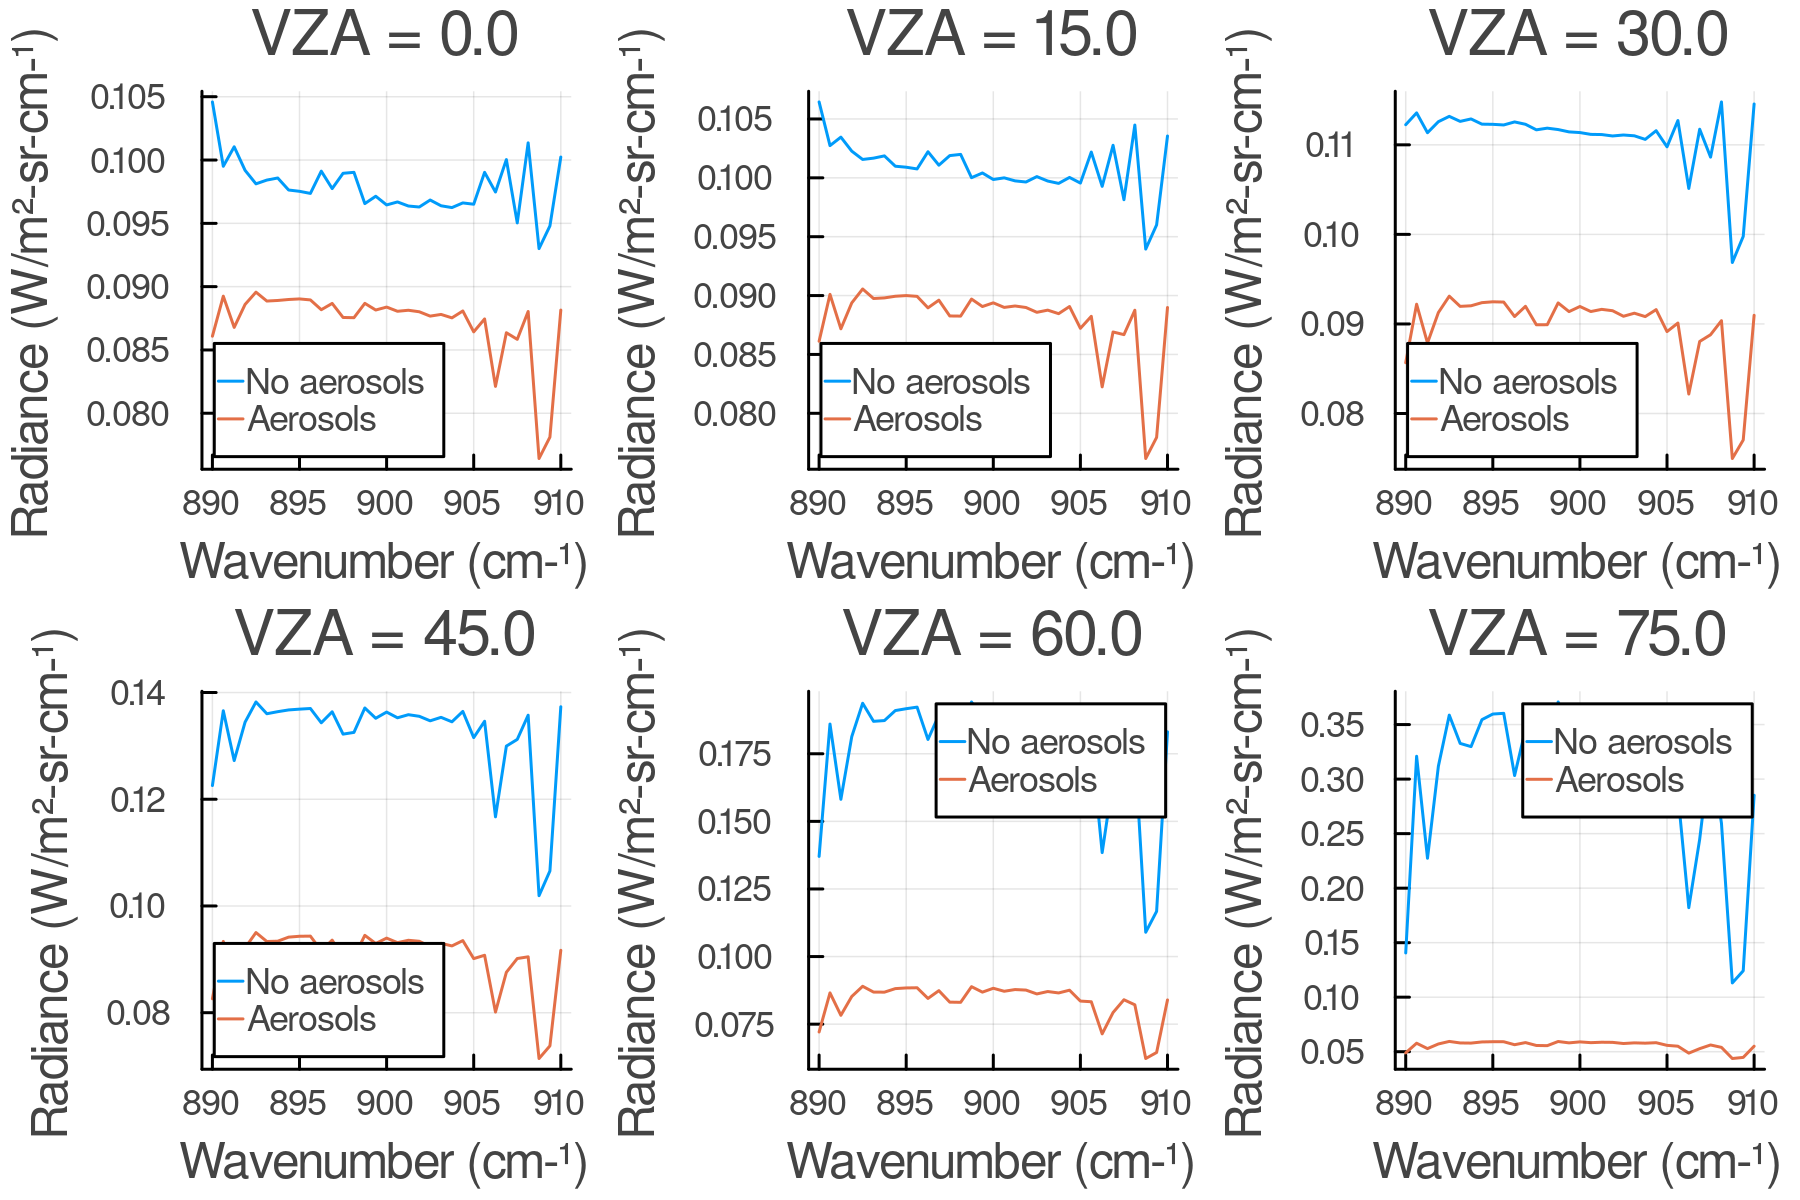

In [235]:
p1 = plot_multiple_zenith_angles(increasing_albedo_no_aerosols, increasing_albedo, 1)
p2 = plot_multiple_zenith_angles(increasing_albedo_no_aerosols, increasing_albedo, 2)
p3 = plot_multiple_zenith_angles(increasing_albedo_no_aerosols, increasing_albedo, 3)
p4 = plot_multiple_zenith_angles(increasing_albedo_no_aerosols, increasing_albedo, 4)
p5 = plot_multiple_zenith_angles(increasing_albedo_no_aerosols, increasing_albedo, 5)
p6 = plot_multiple_zenith_angles(increasing_albedo_no_aerosols, increasing_albedo, 6)

plot(p1, p2, p3, p4, p5, p6)

In [264]:
# CLEAR, ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies_no_scattering.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;

parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.scattering_params = nothing
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
clear_isop = vSmartMOM.CoreRT.rt_run(model); # Run the model

# CLEAR, NO ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies_no_scattering.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;

parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.scattering_params = nothing
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = 0;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
clear_no_isop = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [257]:
# CLEAR, NO ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;

parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.scattering_params = nothing
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = 0.

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
clear_no_isop = vSmartMOM.CoreRT.rt_run(model); # Run the model

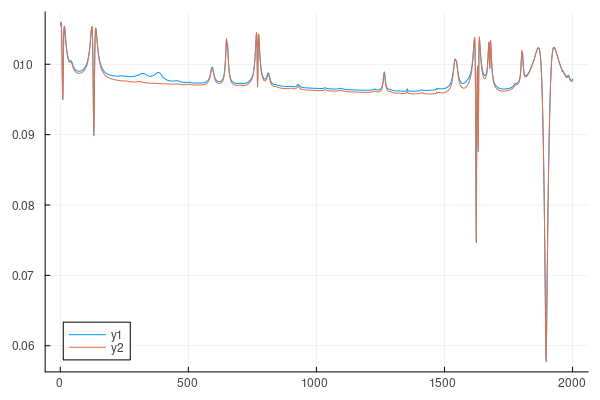

In [263]:
plot(clear_isop[1][1,1,:])
plot!(clear_no_isop[1][1,1,:])

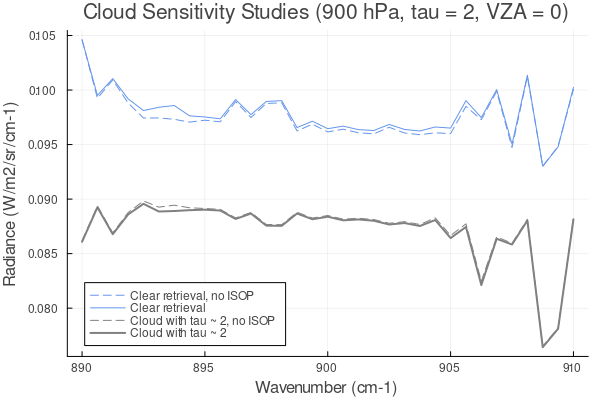

In [262]:
plot(cris_instrument_kernel.ν_out, conv_spectra(cris_instrument_kernel, ν, clear_no_isop[1][1,1,:]), label = "Clear retrieval, no ISOP", color = "cornflowerblue", linestyle =:dash)
plot!(cris_instrument_kernel.ν_out,conv_spectra(cris_instrument_kernel, ν, clear_isop[1][1,1,:]), label = "Clear retrieval", color = "cornflowerblue")

plot!(cris_instrument_kernel.ν_out,conv_spectra(cris_instrument_kernel, ν, increasing_albedo_no_ISOP[1][1,1,:]), label = "Cloud with tau ~ 2, no ISOP", color = "gray", linestyle=:dash)
plot!(cris_instrument_kernel.ν_out,conv_spectra(cris_instrument_kernel, ν, increasing_albedo[1][1,1,:]), label = "Cloud with tau ~ 2", lw = 2, color = "gray")
title!("Cloud Sensitivity Studies (900 hPa, tau = 2, VZA = 0)")
xlabel!("Wavenumber (cm-1)")
ylabel!("Radiance (W/m2/sr/cm-1)")

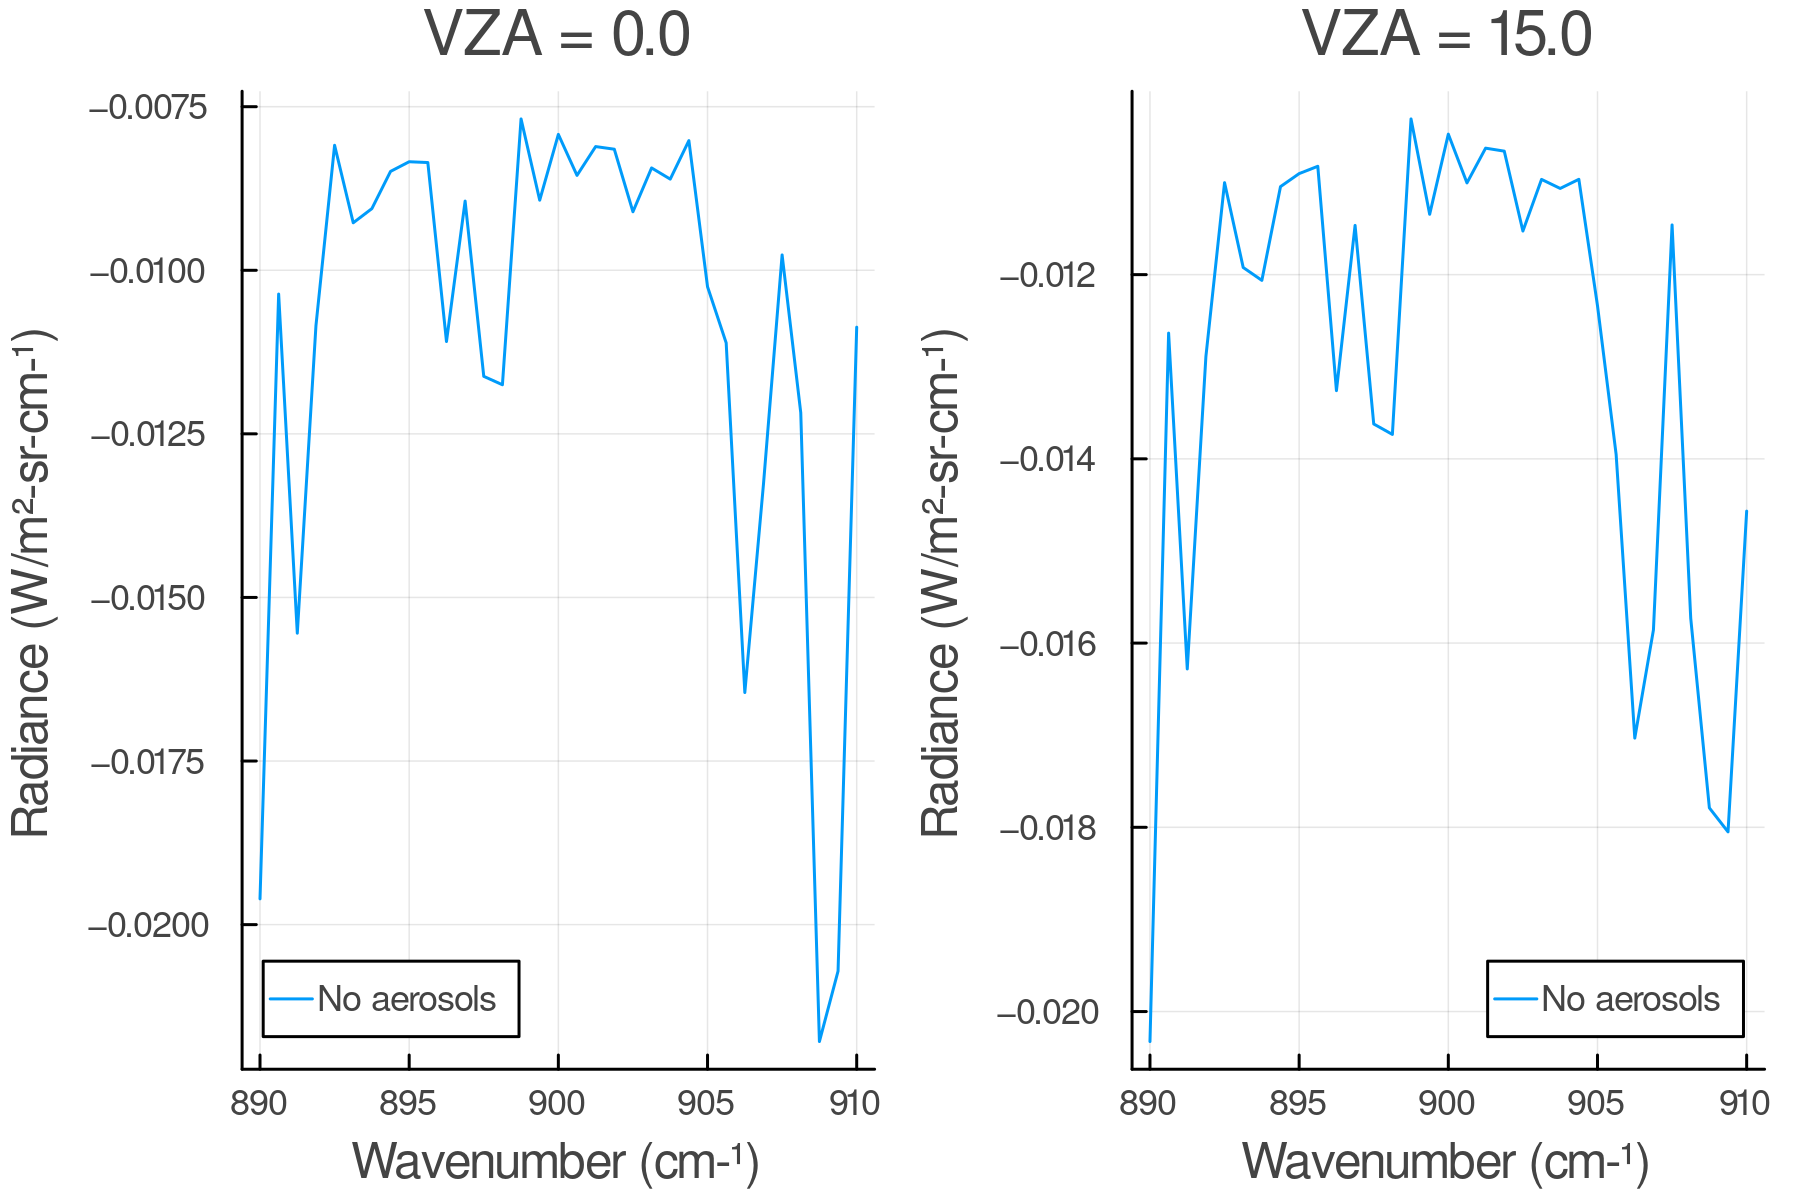

In [241]:
p1 = plot_multiple_zenith_angles_difference(increasing_albedo_no_aerosols, increasing_albedo_no_aerosols_no_ISOP, 1)
p2 = plot_multiple_zenith_angles_difference(increasing_albedo_no_aerosols, increasing_albedo, 2)
plot(p1, p2)

# Different albedos on absorption

In [117]:
# Aerosols, albedo = 0
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_1 = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Aerosols, albedo = 0.1
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.1)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_2 = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Aerosols, albedo = 0.3
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.3)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_3 = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:06


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr 3.0e-9 for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:47


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:02


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:02


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               70.2s /  91.5%           73.5GiB /  96.6%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    56.6s   88.1%   14.2s   50.3GiB   70.9%  12.6GiB
RT Kernel                       216    7.31s   11.4%  33.8ms   17.0GiB   23.9%  80.4MiB
  interaction                   213    5.41s    8.4%  25.4ms   16.9GiB   23.8%  81.0MiB
    interaction inv1 bla        213    1.37s    2.1%  6.45ms   4.21GiB    5.9%  20.2MiB
    interaction inv2            213    1.36s    2.1%  6.40ms   4.21GiB    5.9%  20.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [131]:
function plot_multiple_zenith_angles(spectrum_1, spectrum_2, spectrum_3, index)
    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_1[1][index,1,:]);

    if index == 1
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "Albedo = 0", lw = 2, dpi = 600)
    else
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2, dpi = 600)
    end

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_2[1][index,1,:]);
    if index == 1
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "Albedo = 0.1", lw = 2)
    else
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2)
    end

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_3[1][index,1,:]);
    if index == 1
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "Albedo = 0.3", lw = 2)
    else
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2)
    end

    title!("VZA = $(parameters.vza[index])")
    xlabel!("Wavenumber (cm-¹)")
    ylabel!("Radiance (W/m²-sr-cm-¹)")
    return p
end

plot_multiple_zenith_angles (generic function with 2 methods)

In [134]:
p1 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 1)
p2 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 2)
p3 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 3)
p4 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 4)
p5 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 5)
p6 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 6)

p = plot(p1, p2, p3, p4, p5, p6, size = (900,600), left_margin = 4Plots.mm)
savefig(p, "Figures/albedo_absorption.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/Figures/albedo_absorption.png"

# Different optical depths

In [ ]:
# Aerosols, albedo = 0
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
control = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [145]:
# Aerosols, albedo = 0
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
parameters.scattering_params.rt_aerosols[1].τ_ref = 15.1

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
optical_depth_1 = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Aerosols, albedo = 0.1
# parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
# parameters.T = temperatures;
# parameters.p = pressures;
# parameters.q = specific_humidity;
# parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
# parameters.scattering_params.rt_aerosols[1].τ_ref = 15.1
# parameters.scattering_params.rt_aerosols[1].aerosol.size_distribution.μ = 11.8
# parameters.scattering_params.rt_aerosols[1].aerosol.size_distribution.σ = 5
# parameters.scattering_params.rt_aerosols[1].profile.μ = 70000
# parameters.scattering_params.rt_aerosols[1].profile.σ = 1000

# model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
# optical_depth_2 = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Aerosols, albedo = 0.3
# parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
# parameters.T = temperatures;
# parameters.p = pressures;
# parameters.q = specific_humidity;
# parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.15)
# parameters.scattering_params.rt_aerosols[1].τ_ref = 100

# model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
# optical_depth_3 = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr 3.0e-9 for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:49


...

Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:13


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               1140s /  33.5%            449GiB /  96.5%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                 24     340s   89.1%   14.2s    302GiB   69.6%  12.6GiB
RT Kernel                       221    39.7s   10.4%   179ms    124GiB   28.5%   573MiB
  doubling                      216    32.6s    8.5%   151ms    107GiB   24.6%   505MiB
    Batch Inv Doubling        2.27k    17.0s    4.5%  7.49ms   44.9GiB   10.4%  20.2MiB
  interaction                   213    5.20s    1.4%  24.4ms   16.9GiB    3.9%  81.0MiB
    interaction inv1 bla       

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


([0.09020709834823334; 0.08847670533684596; … ; 0.061805232486097886; 0.04601215638804147;;; 0.08792989261623949; 0.08622929913204053; … ; 0.060186442341009144; 0.044808292874419314;;; 0.085240084565688; 0.08357643704329798; … ; 0.058283374444868655; 0.043392778321281716;;; … ;;; 0.0981462368086761; 0.09634415495503479; … ; 0.06760404963092424; 0.050320897423061464;;; 0.09801871227981593; 0.09621801268565078; … ; 0.06751206135391226; 0.050252558514084694;;; 0.09784280327801065; 0.0960438002087292; … ; 0.06738332080698908; 0.050156935557718295], [0.08319603573106642; 0.08511698500173387; … ; 0.1332217494797492; 0.18890305693068163;;; 0.0839695150800088; 0.08584485681654082; … ; 0.13241927815220253; 0.18671278664317598;;; 0.0851789755961968; 0.0869998478884803; … ; 0.13168355716403565; 0.18424467755102575;;; … ;;; 0.07999578615095251; 0.08206312430724391; … ; 0.13516887404030314; 0.19458669325549904;;; 0.07997571689461443; 0.08204038757425124; … ; 0.13508036624124267; 0.19444963489323736

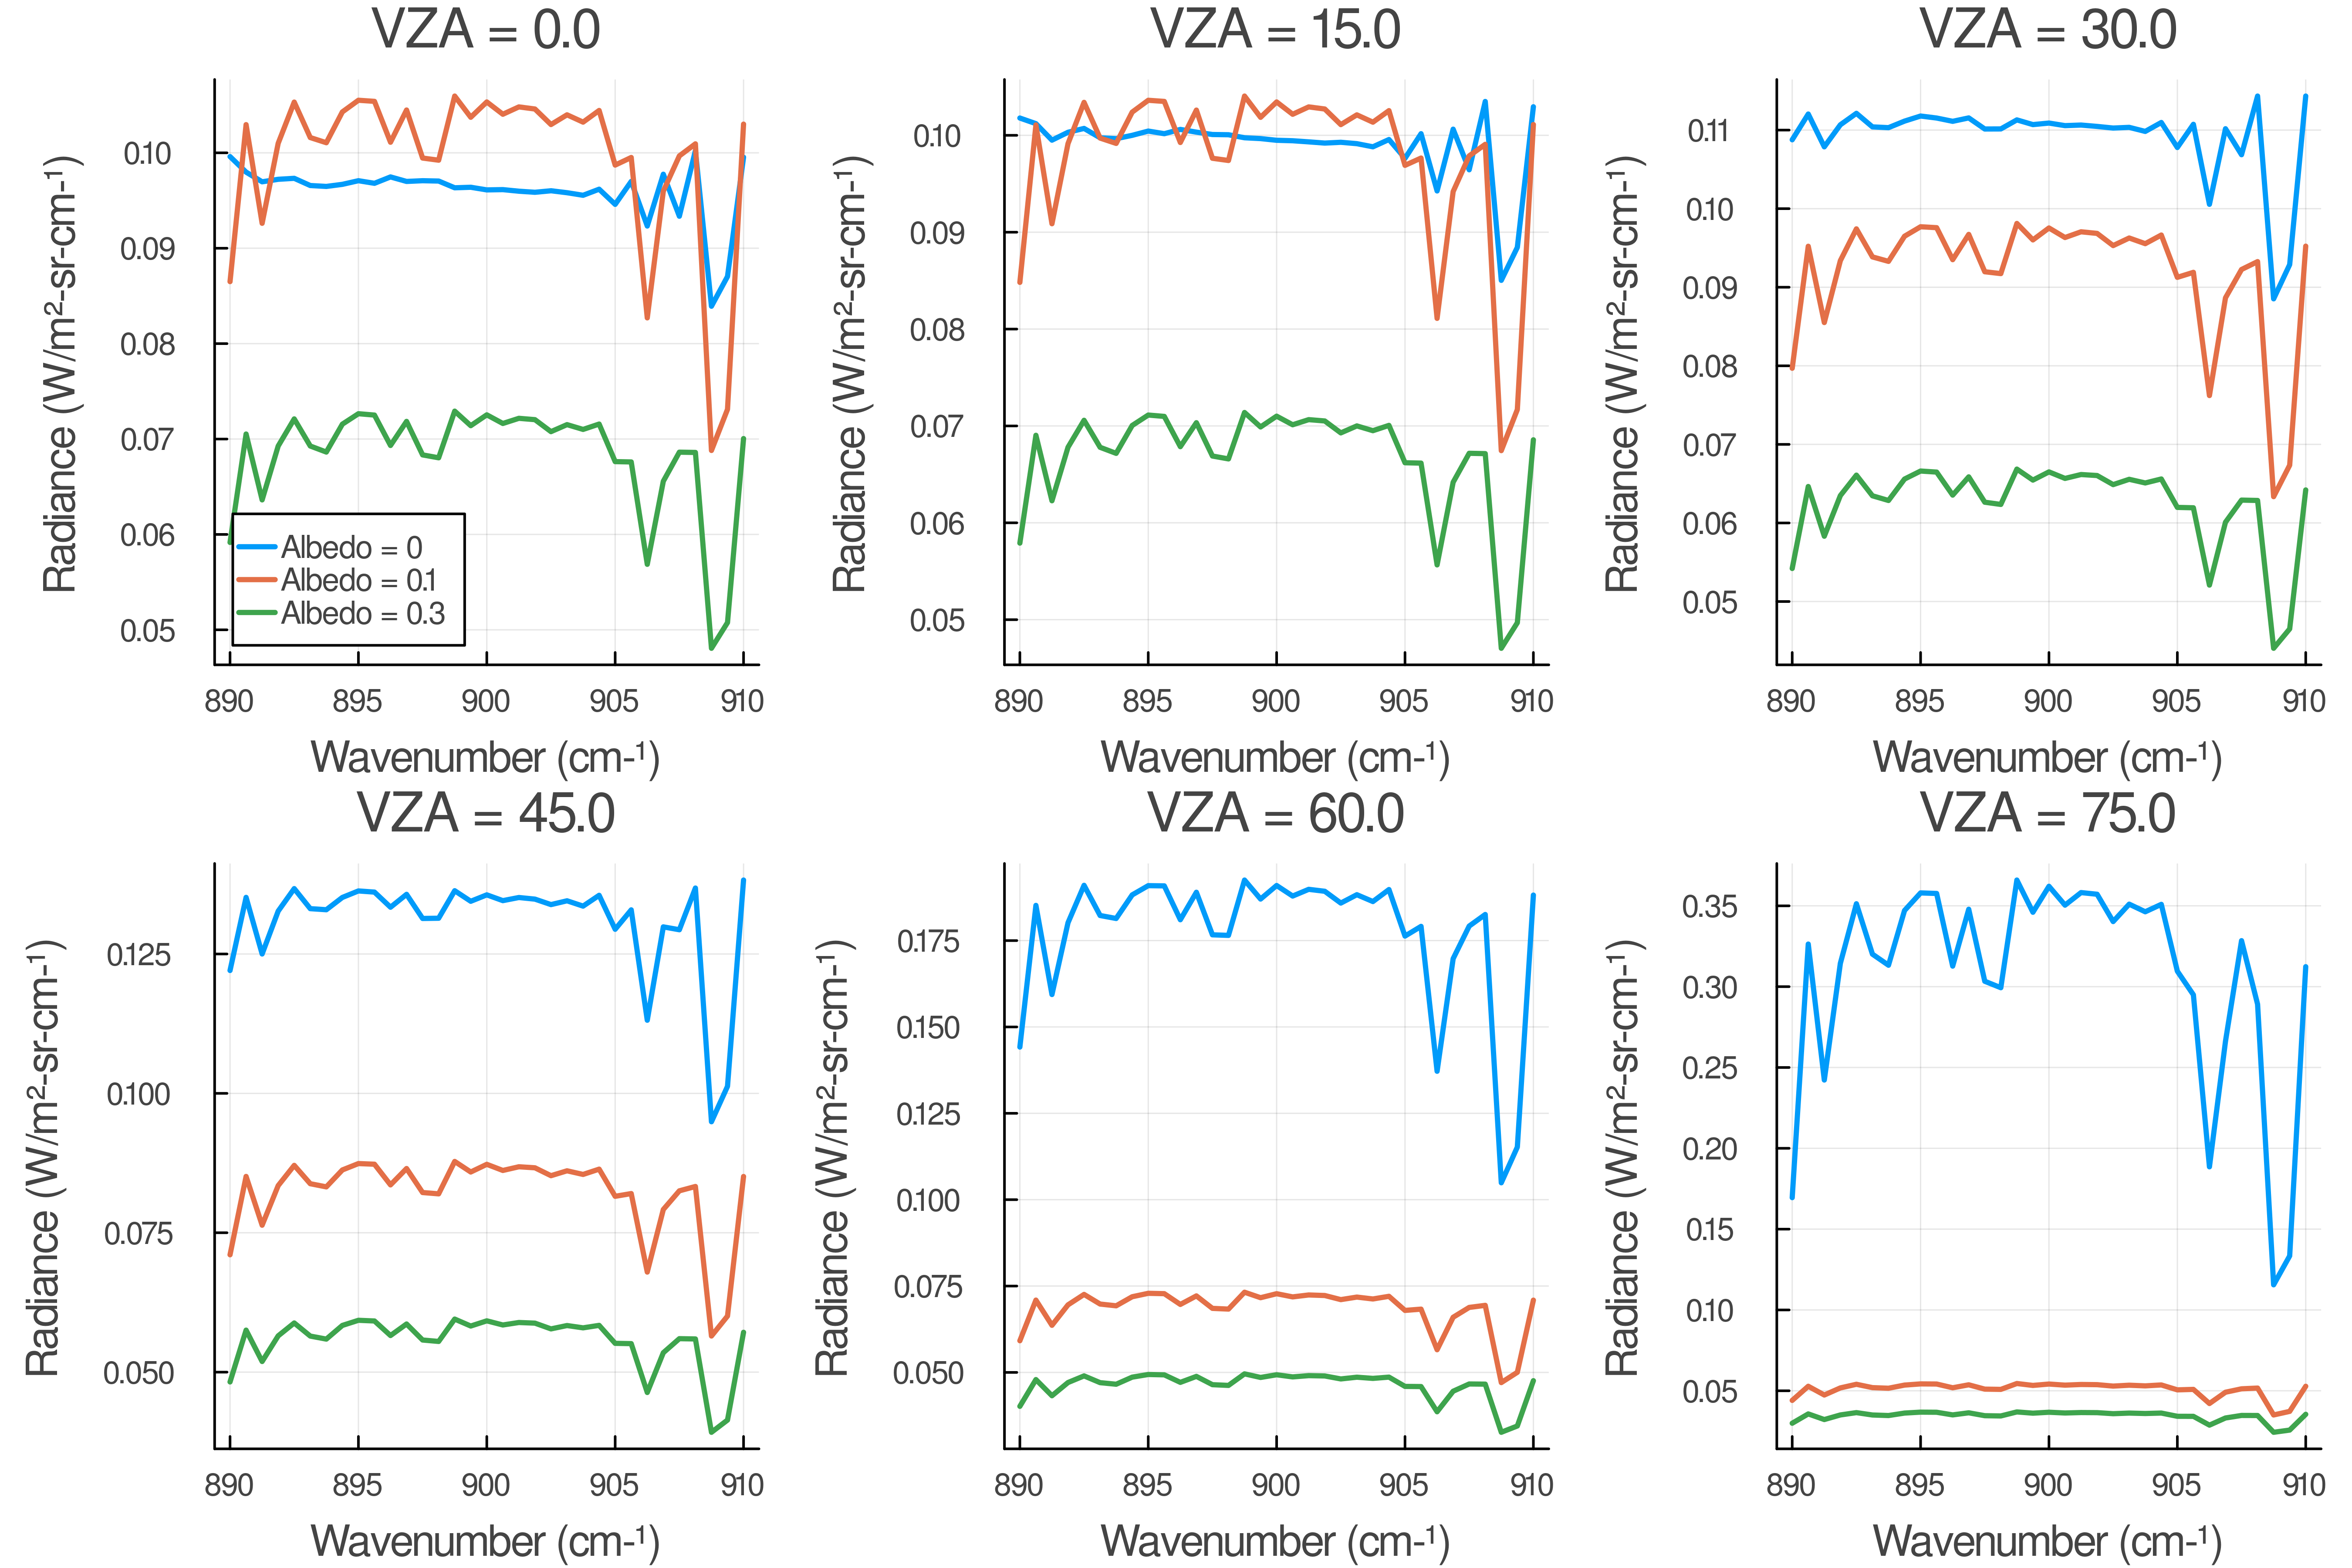

In [146]:
p1 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 1)
p2 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 2)
p3 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 3)
p4 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 4)
p5 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 5)
p6 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 6)

p = plot(p1, p2, p3, p4, p5, p6, size = (900,600), left_margin = 4Plots.mm)
# savefig(p, "Figures/albedo_absorption.png")